# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from preprocesing import preprocess, preprocess_text

# Data Load

In [2]:
df = pd.read_csv("train.csv")

# EDA

In [3]:
print(df.shape)

(120000, 3)


In [4]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
df.columns

Index(['Class Index', 'Title', 'Description'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.7 MB


In [7]:
df.describe()

,Class Index
count,120000.000000
mean,2.500000
std,1.118039
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [8]:
df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["text"] = df["Title"] + " " + df["Description"]

In [11]:
df.head(2)

,Class Index,Title,Description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...


In [12]:
df = df[["Class Index","text"]]

In [13]:
df.head(2)

,Class Index,text
0,3,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...


In [14]:
df.shape

(120000, 2)

In [15]:
df["Class Index"].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

In [16]:
df["Class Index"].value_counts(normalize=True)

Class Index
3    0.25
4    0.25
2    0.25
1    0.25
Name: proportion, dtype: float64

<Axes: xlabel='Class Index', ylabel='count'>

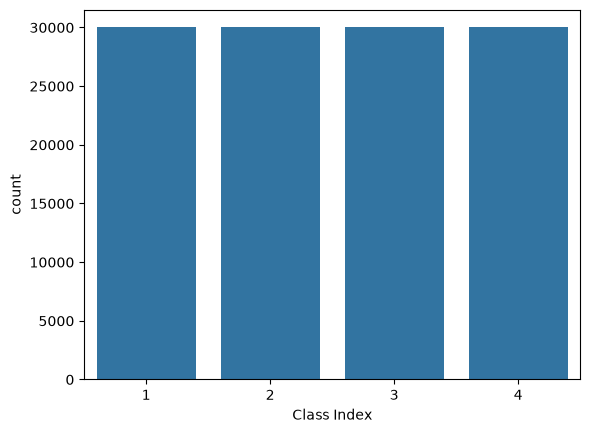

In [17]:
sns.countplot(x=df["Class Index"])

In [18]:
df["text_length"] = df["text"].str.len()

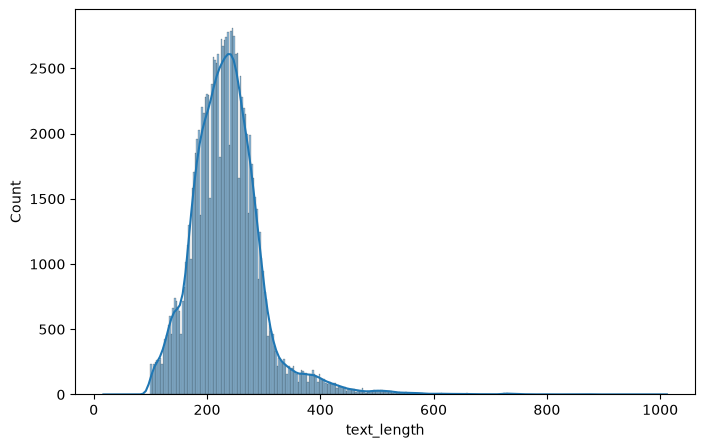

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"],kde=True)
plt.show()

<Axes: xlabel='text_length'>

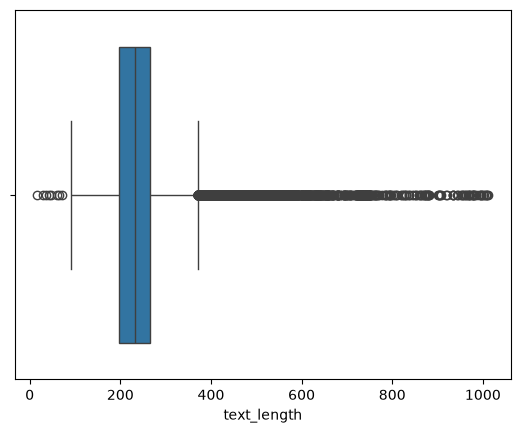

In [20]:
sns.boxplot(x=df["text_length"])

# X and Y split

In [21]:
X = df["text"]

In [22]:
y = df["Class Index"]

# train_test_split

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# Preprocessing

In [24]:
X_train_preprocess = X_train.apply(preprocess)
X_test_preprocess = X_test.apply(preprocess)                           

In [25]:
tfidf = TfidfVectorizer(ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    max_features=10000)
X_train_vec = tfidf.fit_transform(X_train_preprocess)
X_test_vec = tfidf.transform(X_test_preprocess)


# Model Building and Evaluation

# Logistic Regression

In [26]:
lr = LogisticRegression(C=2,max_iter=2000,random_state=42)

lr.fit(X_train_vec,y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfg

In [27]:
lr_pred = lr.predict(X_test_vec)

In [28]:
lr_pred

array([3, 3, 2, ..., 2, 1, 2], shape=(24000,))

In [29]:
confusion_matrix(y_test,lr_pred)

array([[5357,  192,  243,  164],
       [  59, 5919,   46,   34],
       [ 178,   40, 5240,  453],
       [ 207,   57,  437, 5374]])

In [30]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           1       0.92      0.90      0.91      5956
           2       0.95      0.98      0.97      6058
           3       0.88      0.89      0.88      5911
           4       0.89      0.88      0.89      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



# Naive Bayes

In [31]:
nb =  MultinomialNB()
nb.fit(X_train_vec,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](4,)","[24044.,23942.,24089.,23925.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](4,)","[-1.38,-1.39,-1.38,-1.39]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](4,)","[1,2,3,4]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](4, 10000)","[[ 0.63, 2. , 1.3 ,..., 0. , 0. , 0. ], [12.45, 3.03, 0. ,...,21.99,12.9 , 9.65], [ 0. ,13.44, 8.42,..., 0. , 5.18, 0. ], [ 0.28, 4.09, 0.24,..., 0. , 0.52, 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](4, 10000)","[[-11.14,-10.53,-10.8 ,...,-11.63,-11.63,-11.63], [ -8.99,-10.19,-11.59,..., -8.45, -8.96, -9.22], [-11.64, -8.97, -9.4 ,...,-11.64, -9.82,-11.64], [-11.32, -9.94,-11.36,...,-11.57,-11.15,-11.57]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [32]:
nb_pred = nb.predict(X_test_vec)

In [33]:
nb_pred 

array([3, 3, 2, ..., 2, 1, 2], shape=(24000,))

In [34]:
confusion_matrix(y_test,nb_pred)

array([[5307,  234,  275,  140],
       [  67, 5932,   27,   32],
       [ 209,   61, 5078,  563],
       [ 238,   68,  455, 5314]])

In [35]:
print(classification_report(y_test,nb_pred))

              precision    recall  f1-score   support

           1       0.91      0.89      0.90      5956
           2       0.94      0.98      0.96      6058
           3       0.87      0.86      0.86      5911
           4       0.88      0.87      0.88      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000



# SVM

In [36]:
svm = LinearSVC(C=2,max_iter=10000,random_state=42)

svm.fit(X_train_vec,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",10000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are sup

In [37]:
svm_pred = svm.predict(X_test_vec)

In [38]:
svm_pred

array([3, 3, 2, ..., 2, 1, 2], shape=(24000,))

In [39]:
confusion_matrix(y_test,svm_pred)

array([[5327,  188,  265,  176],
       [  67, 5903,   50,   38],
       [ 207,   57, 5186,  461],
       [ 212,   56,  457, 5350]])

In [40]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           1       0.92      0.89      0.91      5956
           2       0.95      0.97      0.96      6058
           3       0.87      0.88      0.87      5911
           4       0.89      0.88      0.88      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



In [41]:
lr_acc = lr.score(X_test_vec, y_test)
nb_acc = nb.score(X_test_vec, y_test)
svm_acc = svm.score(X_test_vec, y_test)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Linear SVM"],
    "Accuracy": [lr_acc, nb_acc, svm_acc]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.912083
2           Linear SVM  0.906917
1          Naive Bayes  0.901292


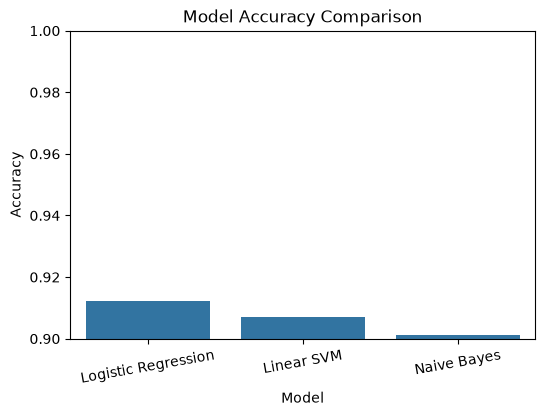

In [42]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Model", y="Accuracy")
plt.ylim(0.90, 1.00)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=10)
plt.show()

# Final Model Pipeline  ( Model = Logistic Regression)

In [43]:
model = Pipeline([
    ("preprocessing",FunctionTransformer(preprocess_text,validate=False)),
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    max_features=10000)),
     ("lr",LogisticRegression(C=2,max_iter=2000,random_state=42))
])
     

In [44]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('tfidf', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[1,2,3,4]"
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function pre...001A940FE4900>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True


In [45]:
y_pred = model.predict(X_test)

In [46]:
y_pred

array([3, 3, 2, ..., 2, 1, 2], shape=(24000,))

In [47]:
model.score(X_test,y_test)

0.9120833333333334

In [48]:
confusion_matrix(y_test,y_pred)

array([[5357,  192,  243,  164],
       [  59, 5919,   46,   34],
       [ 178,   40, 5240,  453],
       [ 207,   57,  437, 5374]])

In [49]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.92      0.90      0.91      5956
           2       0.95      0.98      0.97      6058
           3       0.88      0.89      0.88      5911
           4       0.89      0.88      0.89      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



In [50]:
model.predict(["Apple has unveiled its latest AI-powered iPhone with improved battery life, faster performance, and advanced on-device artificial intelligence features. The company expects strong global demand after the launch."])

array([4])

In [51]:
model.predict(["The Indian cricket team defeated Australia by six wickets in the final match to win the championship after an outstanding batting performance."])

array([2])

In [52]:
model.predict(["Global stock markets rose today as investors welcomed lower inflation data and positive earnings reports from major companies."])

array([3])

In [53]:
model.predict(["The United Nations held an emergency meeting to discuss the ongoing conflict and called for an immediate ceasefire between the two countries."])

array([1])

In [54]:
import pickle

with open("model.pkl","wb") as f:
    pickle.dump(model ,f)